<a href="https://colab.research.google.com/github/Silvia-Guidi/Similarity-project/blob/main/Similairty_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
from collections import defaultdict
from numba import njit
import itertools
import gc
import os
import zipfile
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import mmh3
import random
import time
from concurrent.futures import ProcessPoolExecutor
import string

print(f"Available CPU cores: {os.cpu_count()}")

Available CPU cores: 2


# Data Import

In [ ]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
!kaggle datasets download -d cornell-university/arxiv

zip_path = 'arxiv.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extract('arxiv-metadata-oai-snapshot.json')

Dataset URL: https://www.kaggle.com/datasets/cornell-university/arxiv
License(s): CC0-1.0
arxiv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
USE_WHOLE_DATA = False
SUBSET_SIZE = 50000

def load_arxiv(file_path, use_whole=False, limit=50000):
  data = []
  with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
      if not use_whole and i >= limit:
        break
      entry = json.loads(line)
      data.append({
          'id': entry['id'],
          'abstract': entry['abstract']
            })

  return pd.DataFrame(data)

# Functions

In [ ]:
random.seed(42)
np.random.seed(42)

In [ ]:
FAST_TABLE = str.maketrans("", "", string.punctuation)
N_HASHES = 100
PRIME = 4294967311
MAX_CORES = os.cpu_count() or 1

np.random.seed(42)
A = np.random.randint(1, PRIME, size=N_HASHES, dtype=np.uint64)
B = np.random.randint(0, PRIME, size=N_HASHES, dtype=np.uint64)

@njit
def minhash_core(shingle_hashes, a_coeffs, b_coeffs, prime):
    sig = np.full(len(a_coeffs), 0xFFFFFFFF, dtype=np.uint32)
    for h_val in shingle_hashes:
        hashes = (a_coeffs * h_val + b_coeffs) % prime
        for i in range(len(a_coeffs)):
            if hashes[i] < sig[i]:
                sig[i] = hashes[i]
    return sig

def signature(text):
    if not isinstance(text, str) or len(text) < 9:
        return np.full(N_HASHES, 0xFFFFFFFF, dtype=np.uint32)

    text = text.lower().translate(FAST_TABLE)

    k = 9
    shingle_hashes = np.array([
        mmh3.hash(text[i:i+k]) & 0xFFFFFFFF
        for i in range(len(text)-k+1)
    ], dtype=np.uint64)

    if len(shingle_hashes) == 0:
        return np.full(N_HASHES, 0xFFFFFFFF, dtype=np.uint32)

    return minhash_core(shingle_hashes, A, B, PRIME)

def minhash(texts, num_docs, n_workers=MAX_CORES):
    filename = 'signatures_3M.dat'
    sig_matrix = np.memmap(filename, dtype='uint32', mode='w+', shape=(100, num_docs))

    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        gen = executor.map(signature, texts, chunksize=5000)
        for i, res in enumerate(gen):
            sig_matrix[:, i] = res
    sig_matrix.flush()
    return sig_matrix

def lsh_candidates_optimized(sig_matrix, b, r):
    n_hashes, num_docs = sig_matrix.shape
    candidate_pairs = set()

    for band_idx in range(b):
        start, end = band_idx * r, (band_idx + 1) * r
        buckets = defaultdict(list)

        for doc_id in range(num_docs):
            band_key = sig_matrix[start:end, doc_id].tobytes()
            buckets[band_key].append(doc_id)

        for doc_ids in buckets.values():
            if len(doc_ids) > 1:
                for pair in itertools.combinations(sorted(doc_ids), 2):
                    candidate_pairs.add(pair)

    return candidate_pairs


def precision(candidates, sig_matrix, threshold=0.55, sample_size=100):
    if not candidates:
        return 0.0

    sample = random.sample(list(candidates), min(len(candidates), sample_size))

    true_positives = 0
    for idx1, idx2 in sample:
        sim = np.mean(sig_matrix[:, idx1] == sig_matrix[:, idx2])
        if sim >= threshold:
            true_positives += 1

    prec = true_positives / len(sample)
    print(f"   Empirical Precision: {prec:.2%}")
    return prec

Theoretical Threshold T: 0.549


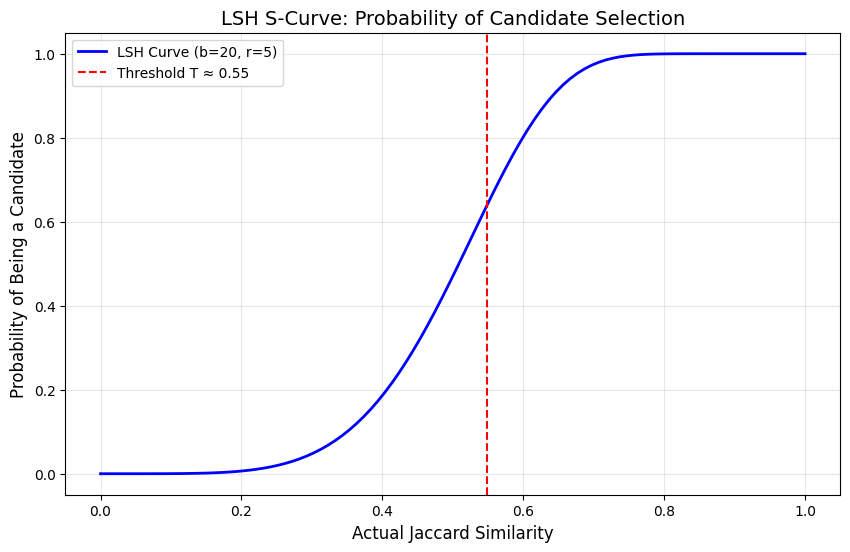

In [ ]:
def plot_lsh_performance(b, r):
    s = np.linspace(0, 1, 100)
    p = 1 - (1 - s**r)**b
    threshold = (1/b)**(1/r)

    plt.figure(figsize=(10, 6))
    plt.plot(s, p, 'b-', linewidth=2, label=f'LSH Curve (b={b}, r={r})')
    plt.axvline(x=threshold, color='r', linestyle='--', label=f'Threshold T ≈ {threshold:.2f}')

    plt.title('LSH S-Curve: Probability of Candidate Selection', fontsize=14)
    plt.xlabel('Actual Jaccard Similarity', fontsize=12)
    plt.ylabel('Probability of Being a Candidate', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('lsh_s_curve.png')
    print(f"Theoretical Threshold T: {threshold:.3f}")


plot_lsh_performance(b=20, r=5)

# Application

In [ ]:
USE_WHOLE_DATA = True

if USE_WHOLE_DATA:
    print("--- RUNNING FULL DATASET PIPELINE ---")
    overall_start = time.time()
    full_df = load_arxiv('arxiv-metadata-oai-snapshot.json', use_whole=True)
    num_docs = len(full_df)

    raw_abstracts = full_df['abstract'].values

    del full_df; gc.collect()

    print(f"Starting MinHash for {len(raw_abstracts)} docs...")
    t0 = time.time()
    sig_mat = minhash(raw_abstracts, num_docs)
    t_minhash = time.time() - t0

    np.save("signatures_checkpoint.npy", sig_mat)
    print("MinHash complete and saved to disk.")

    del raw_abstracts
    gc.collect()

    b, r = 20, 5
    threshold = (1/b)**(1/r)

    print("Starting LSH bucketing...")
    candidates = lsh_candidates_optimized(sig_mat, b=b, r=r)
    t1 = time.time()
    candidates = lsh_candidates_optimized(sig_mat, b=b, r=r)
    t_lsh = time.time() - t1
    total_time = time.time() - overall_start

    print(f"\n--- Pipeline Summary ---")
    print(f"MinHash Time:    {t_minhash:.2f}s")
    print(f"LSH Time:        {t_lsh:.2f}s")
    print(f"Total Execution: {total_time:.2f}s")
    print(f"Found {len(candidates)} candidate pairs.")

    print("\n--- Result Quality Evaluation ---")
    pre = precision(candidates, sig_mat, threshold=threshold)

else:
    print("--- RUNNING SCALABILITY BENCHMARK ---")
    max_size = 100000
    full_data= load_arxiv('arxiv-metadata-oai-snapshot.json', use_whole=False, limit=max_size)

    sizes = [10000, 25000, 50000, 100000]
    results = []
    b, r = 20, 5
    threshold = (1/b)**(1/r)

    for s in sizes:
        print(f"\n>>> Testing size: {s}")
        df_abstracts = full_data['abstract'].iloc[:s].values
        num_docs = len(df_abstracts)

        t_start = time.time()
        sig_mat = minhash(df_abstracts, num_docs, n_workers=2)
        t_minhash = time.time() - t_start
        print(f"   MinHash+Shingle: {t_minhash:.2f}s")

        t_lsh_start = time.time()
        candidates = lsh_candidates_optimized(sig_mat, b=20, r=5)
        t_lsh = time.time() - t_lsh_start
        total = time.time() - t_start
        print(f"   LSH Bucketing:{t_lsh:.2f}s")

        prec = precision(candidates, sig_mat, threshold=threshold)
        print(f"   Total for {s}:{total:.2f}s")

        results.append({'n': s, 'minhash': t_minhash, 'lsh': t_lsh, 'total': total})


df_results = pd.DataFrame(results)

--- RUNNING FULL DATASET PIPELINE ---
Starting MinHash for 2968861 docs...
MinHash complete and saved to disk.
Starting LSH bucketing...

--- Pipeline Summary ---
MinHash Time:    5443.15s
LSH Time:        321.78s
Total Execution: 6181.29s
Found 113952 candidate pairs.

--- Result Quality Evaluation ---
   Empirical Precision: 59.00%


# Scalability Analysis using benchmark

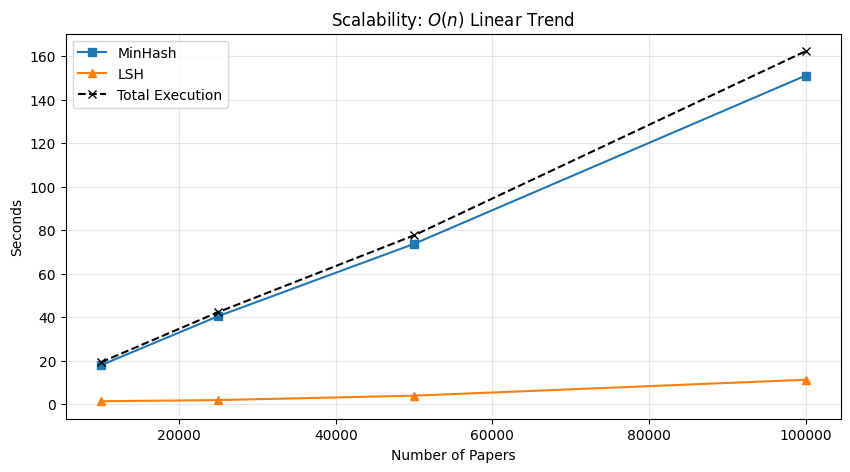

In [ ]:
if not USE_WHOLE_DATA:
  plt.figure(figsize=(10, 5))
  plt.plot(df_results['n'], df_results['minhash'], 's-', label='MinHash')
  plt.plot(df_results['n'], df_results['lsh'], '^-', label='LSH')
  plt.plot(df_results['n'], df_results['total'], 'x--', color='black', label='Total Execution')
  plt.title("Scalability: $O(n)$ Linear Trend")
  plt.xlabel("Number of Papers")
  plt.ylabel("Seconds")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()